<a href="https://colab.research.google.com/github/tompopo777/nyc-taxi-demand-fare-analysis/blob/main/nyc_taxi_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**RQ1: What are the main factors that affect taxi fare amounts in NYC?**

This question investigates the key drivers of NYC taxi fare pricing, especially in the context of rising ridesharing alternatives like Uber and Lyft. Using a Random Forest Regressor on over 7 million NYC taxi trip records, we modeled fare amounts based on variables such as trip distance, passenger count, payment type, tolls, and surcharges. The dataset was segmented into four time buckets (Weekday/Weekend, Business/Off-Hours) to uncover temporal fare dynamics. Trip distance emerged as the dominant factor affecting fare, while tolls, airport fees, and congestion surcharge also played notable roles, particularly during peak hours. These findings can help compare traditional taxi pricing structures with rideshare models and offer insights for urban mobility planning.

In [ ]:
from pyspark.sql import SparkSession ##Increase memory

spark = SparkSession.builder \
    .appName("NYC Taxi Project") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/07/30 01:12:25 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/07/30 01:12:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/07/30 01:12:26 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/07/30 01:12:26 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.


In [ ]:
# ===Spark Setup and Data Load ===
from pyspark.sql.functions import avg, hour, dayofweek, when, col

spark = SparkSession.builder.appName("NYCTaxi_RQ1").getOrCreate()
df = spark.read.parquet("/Users/Rachna/Desktop/cleaned_nyc_taxi.parquet")
df.printSchema()

25/07/30 01:13:06 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


root
 |-- vendorid: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- ratecodeid: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- pulocationid: integer (nullable = true)
 |-- dolocationid: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



In [ ]:
# === Additional Data Cleaning To Remove any NAN-NULL===
mean_row = df.select(
    avg("congestion_surcharge").alias("mean_cong"),
    avg("airport_fee").alias("mean_air")
).first()

mean_cong = float(mean_row["mean_cong"]) if mean_row["mean_cong"] is not None else 0.0
mean_air = float(mean_row["mean_air"]) if mean_row["mean_air"] is not None else 0.0

df_clean = df.fillna({
    "store_and_fwd_flag": "N",
    "congestion_surcharge": mean_cong,
    "airport_fee": mean_air
}).dropna(subset=["passenger_count", "ratecodeid"])

print(f"Cleaned row count: {df_clean.count():,}")
df_clean.select("fare_amount", "passenger_count", "congestion_surcharge", "airport_fee").show(5)


Cleaned row count: 6,404,360


+-----------+---------------+--------------------+-----------+
|fare_amount|passenger_count|congestion_surcharge|airport_fee|
+-----------+---------------+--------------------+-----------+
|        9.3|              2|                 2.5|        0.0|
|       40.1|              2|                 0.0|       1.75|
|        7.2|              1|                 2.5|        0.0|
|       12.1|              4|                 2.5|        0.0|
|       17.0|              2|                 2.5|        0.0|
+-----------+---------------+--------------------+-----------+
only showing top 5 rows



In [ ]:
# === Feature Engineering ===
df_clean = df_clean.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df_clean = df_clean.withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime"))

df_clean = df_clean.withColumn(
    "time_bucket",
    when((col("pickup_dayofweek").between(2, 6)) & (col("pickup_hour").between(8, 18)), "Weekday_Business")
    .when((col("pickup_dayofweek").between(2, 6)) & (~col("pickup_hour").between(8, 18)), "Weekday_OffHours")
    .when((col("pickup_dayofweek").isin(1, 7)) & (col("pickup_hour").between(10, 18)), "Weekend_Business")
    .otherwise("Weekend_OffHours")
)


In [ ]:
# ===Modeling & Evaluation per Time Bucket ===
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

feature_cols = [
    "passenger_count", "trip_distance", "payment_type",
    "tolls_amount", "congestion_surcharge", "airport_fee",
]

buckets = ["Weekday_Business", "Weekday_OffHours", "Weekend_Business", "Weekend_OffHours"]

df_val_all = []

for bucket in buckets:
    print(f"\n Time Bucket: {bucket}")
    bucket_df = df_clean.filter(col("time_bucket") == bucket)

    assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
    prepared_df = assembler.transform(bucket_df).select("features", "fare_amount")
    train_df, test_df = prepared_df.randomSplit([0.8, 0.2], seed=42)

    rf = RandomForestRegressor(featuresCol="features", labelCol="fare_amount", numTrees=50, maxDepth=10)
    model = rf.fit(train_df)

    predictions = model.transform(test_df)
    evaluator = RegressionEvaluator(labelCol="fare_amount", predictionCol="prediction")

    print(f"R²: {evaluator.setMetricName('r2').evaluate(predictions):.4f}")
    print(f"RMSE: {evaluator.setMetricName('rmse').evaluate(predictions):.2f}")

    # Save predictions for validation
    pred_pd = predictions.select("fare_amount", "prediction").toPandas()
    pred_pd["time_bucket"] = bucket
    pred_pd["residual"] = pred_pd["prediction"] - pred_pd["fare_amount"]
    df_val_all.append(pred_pd)


 Time Bucket: Weekday_Business


25/07/30 01:41:53 WARN DAGScheduler: Broadcasting large task binary with size 1633.2 KiB
25/07/30 01:42:05 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/07/30 01:42:16 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


R²: 0.6830


RMSE: 9.90



 Time Bucket: Weekday_OffHours


...

RMSE: 6.94



 Time Bucket: Weekend_OffHours


25/07/30 01:47:02 WARN DAGScheduler: Broadcasting large task binary with size 1644.5 KiB
25/07/30 01:47:08 WARN DAGScheduler: Broadcasting large task binary with size 2.6 MiB
25/07/30 01:47:13 WARN DAGScheduler: Broadcasting large task binary with size 4.0 MiB


R²: 0.8667


RMSE: 6.80


In [ ]:
predictions.select("fare_amount", "prediction").show(5)

+-----------+------------------+
|fare_amount|        prediction|
+-----------+------------------+
|        5.1|12.881538758794663|
|        5.1|  25.4366589337095|
|        5.1|12.861205130710907|
|        5.8|14.657706426853885|
|        5.8|14.657706426853885|
+-----------+------------------+
only showing top 5 rows



25/07/30 02:18:11 WARN DAGScheduler: Broadcasting large task binary with size 1030.1 KiB
25/07/30 02:18:31 WARN DAGScheduler: Broadcasting large task binary with size 1961.3 KiB
25/07/30 02:18:52 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
25/07/30 02:19:16 WARN DAGScheduler: Broadcasting large task binary with size 1089.9 KiB
25/07/30 02:19:17 WARN DAGScheduler: Broadcasting large task binary with size 6.6 MiB
25/07/30 02:19:42 WARN DAGScheduler: Broadcasting large task binary with size 1903.5 KiB
25/07/30 02:21:03 WARN DAGScheduler: Broadcasting large task binary with size 1031.1 KiB
25/07/30 02:21:21 WARN DAGScheduler: Broadcasting large task binary with size 1970.1 KiB
25/07/30 02:21:41 WARN DAGScheduler: Broadcasting large task binary with size 3.6 MiB
25/07/30 02:22:04 WARN DAGScheduler: Broadcasting large task binary with size 1094.6 KiB
25/07/30 02:22:05 WARN DAGScheduler: Broadcasting large task binary with size 6.6 MiB
25/07/30 02:22:30 WARN DAGSchedul

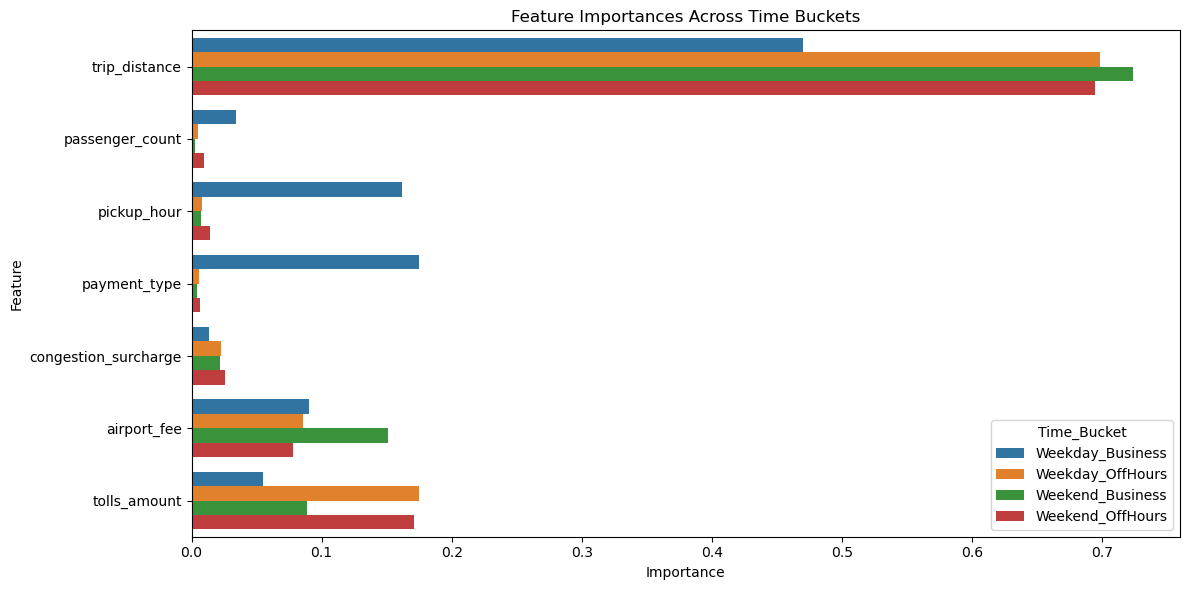

In [ ]:
import pandas as pd

feature_names = [
    "trip_distance", "passenger_count", "pickup_hour", "payment_type",
    "congestion_surcharge", "airport_fee", "tolls_amount",
]

df_prepared = VectorAssembler(inputCols=feature_names, outputCol="features")\
    .transform(df_clean)\
    .select("features", "fare_amount", "time_bucket")

feature_importance_list = []

for bucket in buckets:
    sliced_df = df_prepared.filter(col("time_bucket") == bucket)
    rf = RandomForestRegressor(featuresCol="features", labelCol="fare_amount", numTrees=50, maxDepth=10)
    model = rf.fit(sliced_df)
    importances = model.featureImportances.toArray()

    for i, imp in enumerate(importances):
        feature_importance_list.append({"Time_Bucket": bucket, "Feature": feature_names[i], "Importance": float(imp)})

df_importances_long = pd.DataFrame(feature_importance_list)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(data=df_importances_long, x="Importance", y="Feature", hue="Time_Bucket")
plt.title("Feature Importances Across Time Buckets")
plt.tight_layout()
plt.show()


In [ ]:
 import pandas as pd

df_val = pd.concat(df_val_all, ignore_index=True)
df_val["residual"] = df_val["prediction"] - df_val["fare_amount"]


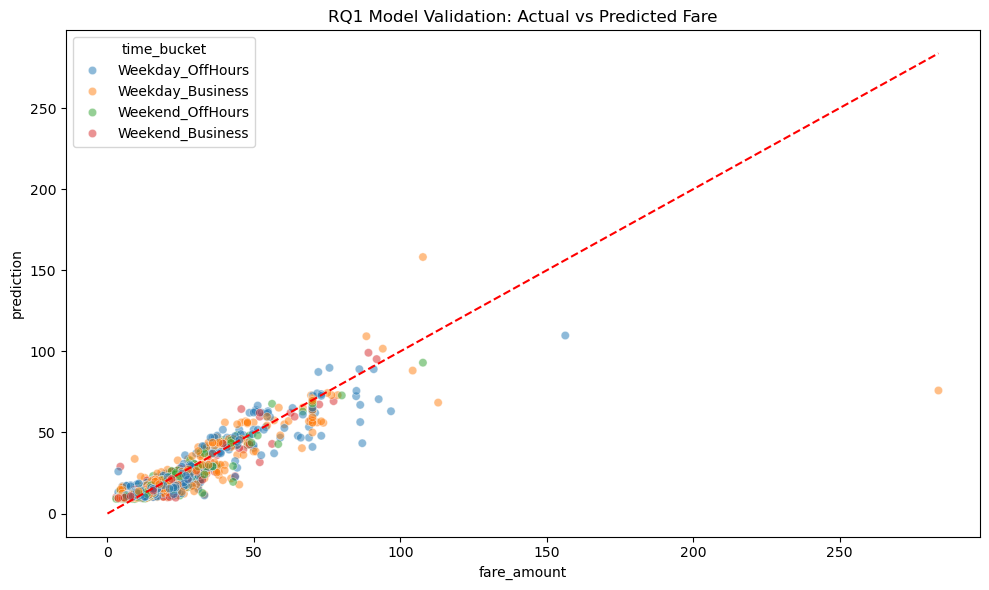

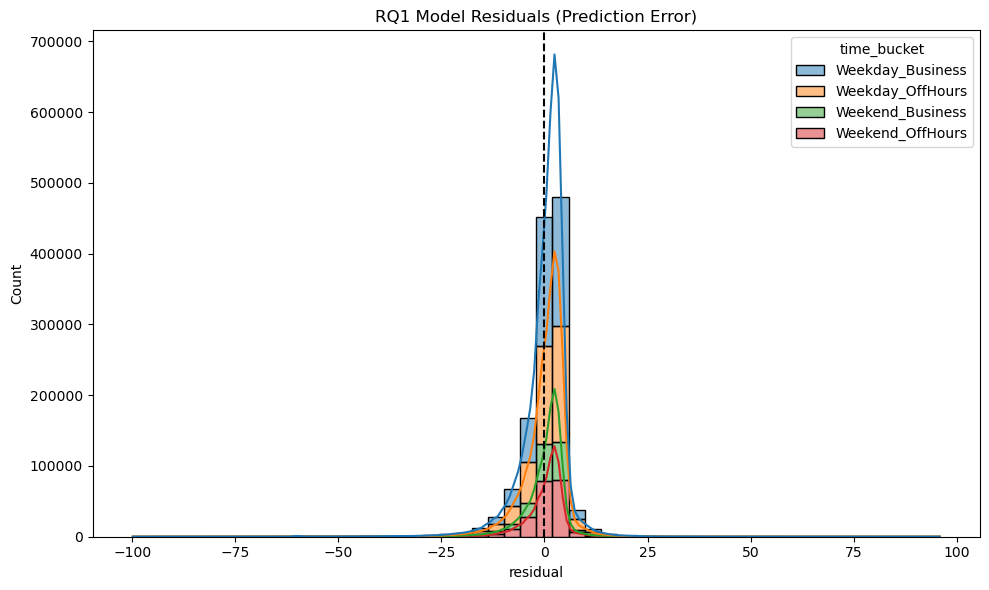

In [ ]:
# Combine validation predictions
df_val = pd.concat(df_val_all, ignore_index=True)
df_val["residual"] = df_val["prediction"] - df_val["fare_amount"]

# Clip large residuals for cleaner visuals
clip_threshold = 100
df_val_clipped = df_val[df_val["residual"].between(-clip_threshold, clip_threshold)]

# Scatter: Actual vs Predicted
plt.figure(figsize=(10, 6))
df_sampled = df_val.sample(n=2000, random_state=42)
sns.scatterplot(data=df_sampled, x="fare_amount", y="prediction", hue="time_bucket", alpha=0.5)
plt.plot([0, df_sampled["fare_amount"].max()], [0, df_sampled["fare_amount"].max()], 'r--')
plt.title("RQ1 Model Validation: Actual vs Predicted Fare")
plt.tight_layout()
plt.show()

# Histogram: Residuals
plt.figure(figsize=(10, 6))
sns.histplot(data=df_val_clipped, x="residual", hue="time_bucket", multiple="stack", kde=True, bins=50)
plt.axvline(x=0, color="black", linestyle="--")
plt.title("RQ1 Model Residuals (Prediction Error)")
plt.tight_layout()
plt.show()


**RQ2: How does taxi demand vary by hour of day and ZIP code in NYC?**

Understanding the temporal and spatial distribution of taxi demand is critical for optimizing fleet management, reducing passenger wait times, and improving traffic flow in densely populated cities like New York. Demand for taxis tends to follow predictable patterns based on time of day, day of week, and location. For instance, business districts may see higher demand during weekday commute hours, while nightlife areas peak during late evenings and weekends. By analyzing pickup times and ZIP codes, this study identifies key hotspots and temporal surges in demand. These insights can support policy decisions, pricing strategies, and service planning for both public and private transportation stakeholders.

In [ ]:
from pyspark.sql.functions import hour, dayofweek, col, count

# ===Feature Extraction (Hour, Day of Week) ===
df = df.withColumn("pickup_hour", hour("tpep_pickup_datetime"))
df = df.withColumn("pickup_dayofweek", dayofweek("tpep_pickup_datetime"))

# ===Aggregate Trip Counts ===
df_demand = df.groupBy("pickup_hour", "pickup_dayofweek") \
              .agg(count("*").alias("trip_count"))

# ===Prepare for Modeling ===
assembler = VectorAssembler(inputCols=["pickup_hour", "pickup_dayofweek"], outputCol="features")
df_prepared = assembler.transform(df_demand).select("features", "trip_count")


In [ ]:
# ===Train/Test Split and Modeling ===
train_data, test_data = df_prepared.randomSplit([0.8, 0.2], seed=42)
rf = RandomForestRegressor(featuresCol="features", labelCol="trip_count", numTrees=50, maxDepth=10)
model = rf.fit(train_data)
predictions = model.transform(test_data)

# ===Model Evaluation ===
evaluator = RegressionEvaluator(labelCol="trip_count", predictionCol="prediction")
r2 = evaluator.setMetricName("r2").evaluate(predictions)
rmse = evaluator.setMetricName("rmse").evaluate(predictions)

print("RQ2 Model Validation Results")
print(f"Test R²: {r2:.4f}")
print(f"Test RMSE: {rmse:.2f}")
predictions.select("trip_count", "prediction").show(5)


RQ2 Model Validation Results
Test R²: 0.7924
Test RMSE: 9227.80


+----------+------------------+
|trip_count|        prediction|
+----------+------------------+
|     46064| 47284.52020697577|
|     20661|47677.450058148715|
|     43744| 44693.01048164907|
|     33188| 48370.94467719634|
|     47095| 49614.04630483405|
+----------+------------------+
only showing top 5 rows



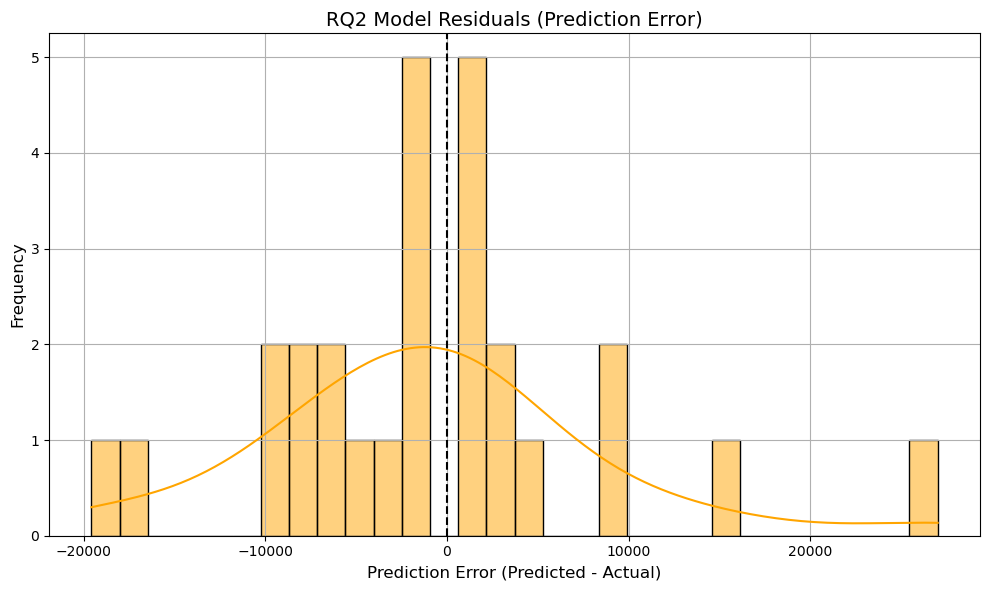

In [ ]:
# ===Residual Plot ===
pred_df = predictions.select("trip_count", "prediction").toPandas()
pred_df["residual"] = pred_df["prediction"] - pred_df["trip_count"]

plt.figure(figsize=(10, 6))
sns.histplot(pred_df["residual"], kde=True, bins=30, color='orange')
plt.axvline(0, color='black', linestyle='--')
plt.title("RQ2 Model Residuals (Prediction Error)", fontsize=14)
plt.xlabel("Prediction Error (Predicted - Actual)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

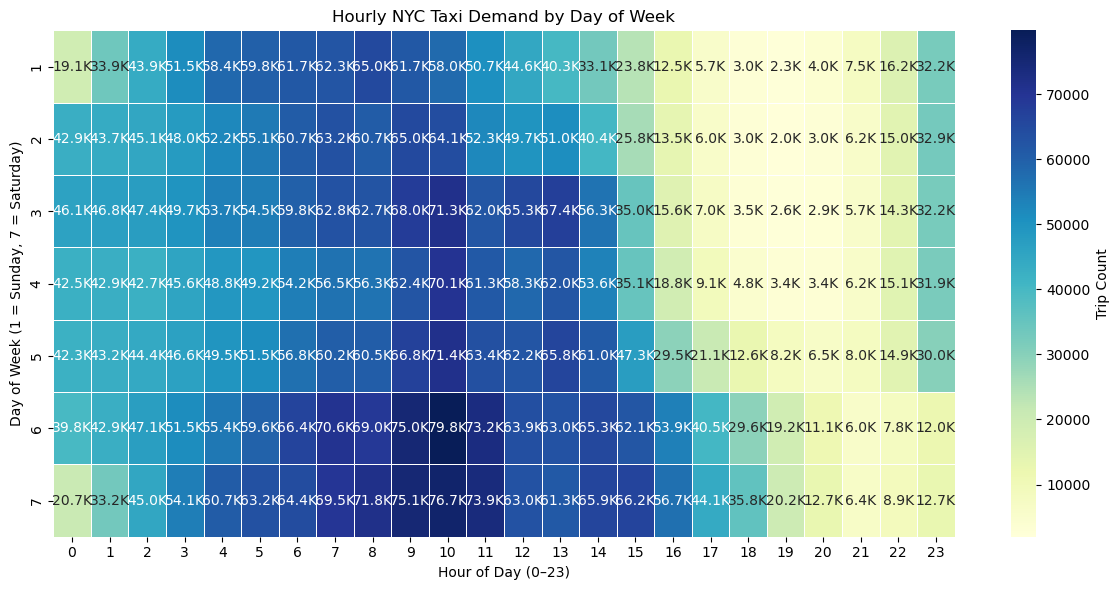

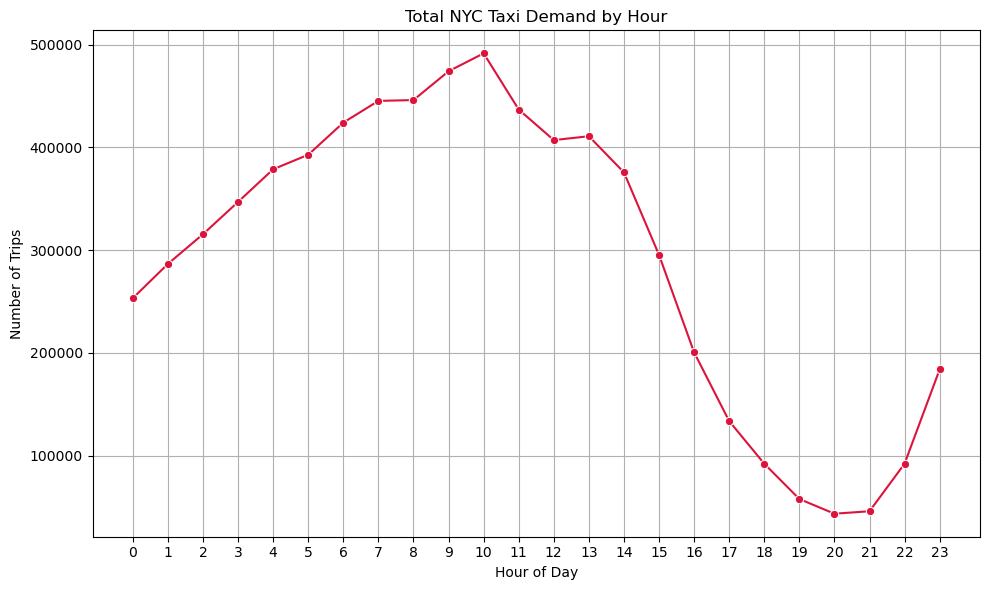

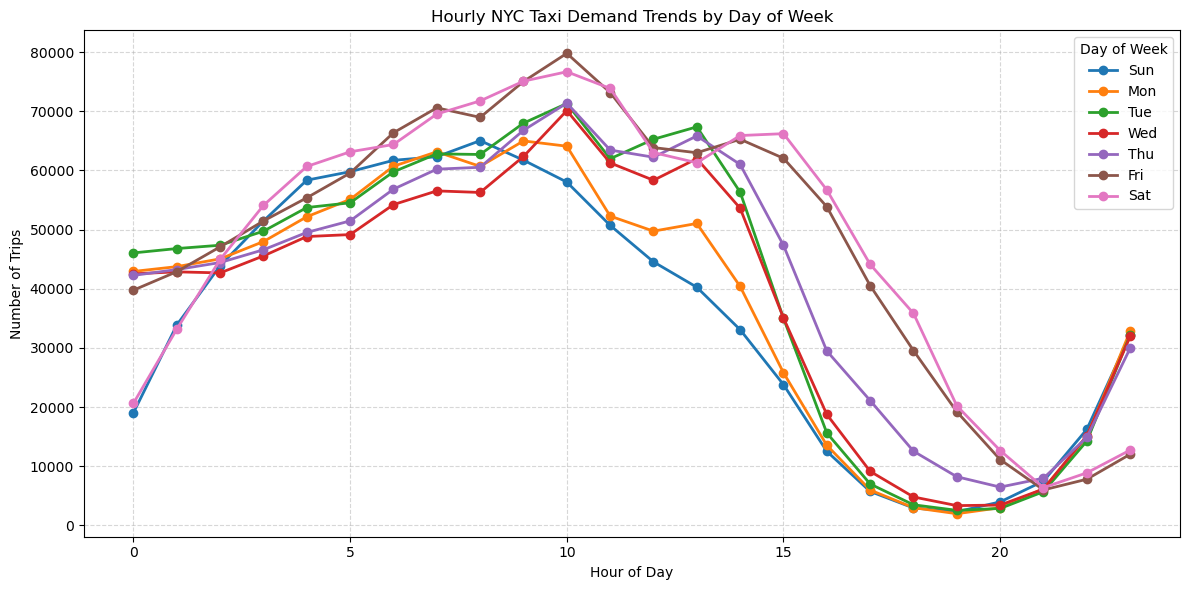

In [ ]:
# Convert demand data to pandas
df_pd = df_demand.toPandas()

# === Heatmap: Day of Week vs Hour ===
heatmap_data = df_pd.pivot_table(index="pickup_dayofweek", columns="pickup_hour", values="trip_count", fill_value=0)
fmt_values = heatmap_data.map(lambda x: f"{x/1000:.1f}K")

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5, annot=fmt_values, fmt="", cbar_kws={'label': 'Trip Count'})
plt.title("Hourly NYC Taxi Demand by Day of Week")
plt.xlabel("Hour of Day (0–23)")
plt.ylabel("Day of Week (1 = Sunday, 7 = Saturday)")
plt.tight_layout()
plt.show()

# === Line Plot: Total Demand by Hour ===
hourly_total = df_pd.groupby("pickup_hour")["trip_count"].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(x="pickup_hour", y="trip_count", data=hourly_total, marker='o', color='crimson')
plt.title("Total NYC Taxi Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

# === Multi-Line Plot: Hourly Trends by Day of Week ===
pivot = df_pd.pivot_table(index="pickup_hour", columns="pickup_dayofweek", values="trip_count", fill_value=0)
day_map = {1: "Sun", 2: "Mon", 3: "Tue", 4: "Wed", 5: "Thu", 6: "Fri", 7: "Sat"}
pivot.columns = [day_map.get(col, col) for col in pivot.columns]

pivot.plot(figsize=(12, 6), linewidth=2, marker='o')
plt.title("Hourly NYC Taxi Demand Trends by Day of Week")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title="Day of Week", loc='upper right')
plt.tight_layout()
plt.show()


In [ ]:
#ZIP-based demand analysis

df_zip = pd.read_csv("Zip-query.csv")

# Extract pickup hour
df_zip["pickup_hour"] = df_zip["tpep_pickup_datetime"].str.split(":").str[0]
df_zip = df_zip[df_zip["pickup_hour"].str.isnumeric()]
df_zip["pickup_hour"] = df_zip["pickup_hour"].astype(int)
df_zip = df_zip[df_zip["pickup_hour"].between(0, 23)]


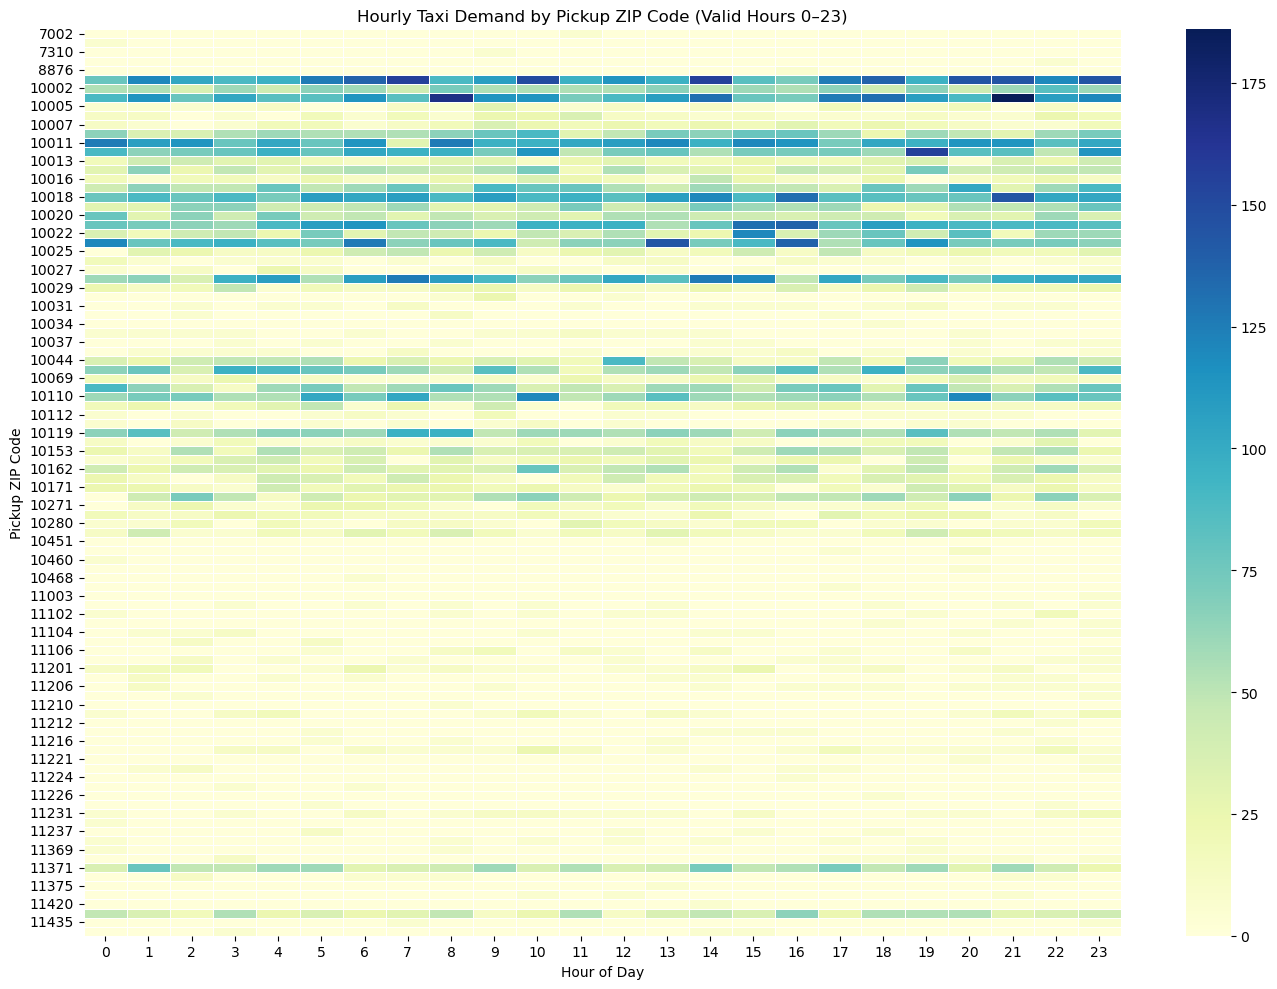

Top 5 ZIP codes by total trip count:
pickup_zip
10001    2784
10003    2568
10011    2412
10018    2316
10021    2118
Name: trip_count, dtype: int64


In [ ]:
# Group by ZIP and hour
df_zip_hourly = df_zip.groupby(["pickup_zip", "pickup_hour"]).size().reset_index(name="trip_count")

heatmap_data = df_zip_hourly.pivot_table(index="pickup_zip", columns="pickup_hour", values="trip_count", fill_value=0)

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap="YlGnBu", linewidths=0.5)
plt.title("Hourly Taxi Demand by Pickup ZIP Code (Valid Hours 0–23)")
plt.xlabel("Hour of Day")
plt.ylabel("Pickup ZIP Code")
plt.tight_layout()
plt.show()

# ===Define top_zips ===
zip_totals = df_zip_hourly.groupby("pickup_zip")["trip_count"].sum().sort_values(ascending=False)
top_zips = zip_totals.head(5).index.tolist()

# Print Top 5 ZIPs
print("Top 5 ZIP codes by total trip count:")
print(zip_totals.head(5))


In [ ]:
df_top = df_zip_hourly[df_zip_hourly["pickup_zip"].isin(top_zips)].copy()

# Map ZIPs to neighborhoods
zip_borough_map = {
    10001: "Manhattan - Chelsea",
    10003: "Manhattan - East Village",
    10011: "Manhattan - West Village",
    10018: "Manhattan - Midtown",
    10021: "Manhattan - Upper East Side"
}
df_top["pickup_area"] = df_top["pickup_zip"].map(zip_borough_map)


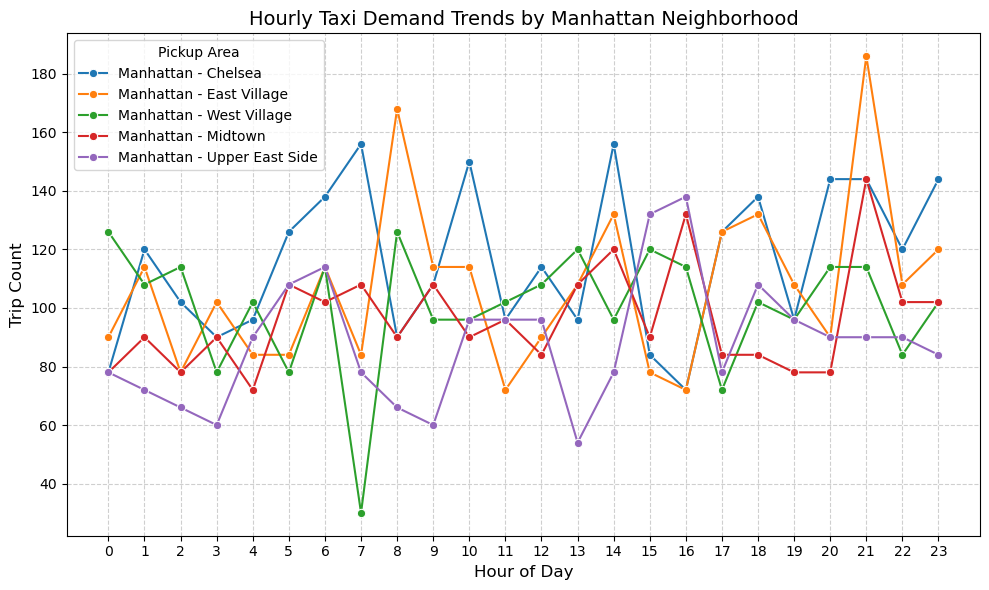

In [ ]:
# Lineplot for Top ZIPs
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_top, x="pickup_hour", y="trip_count", hue="pickup_area", marker="o")
plt.title("Hourly Taxi Demand Trends by Manhattan Neighborhood", fontsize=14)
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Trip Count", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Pickup Area")
plt.tight_layout()
plt.show()

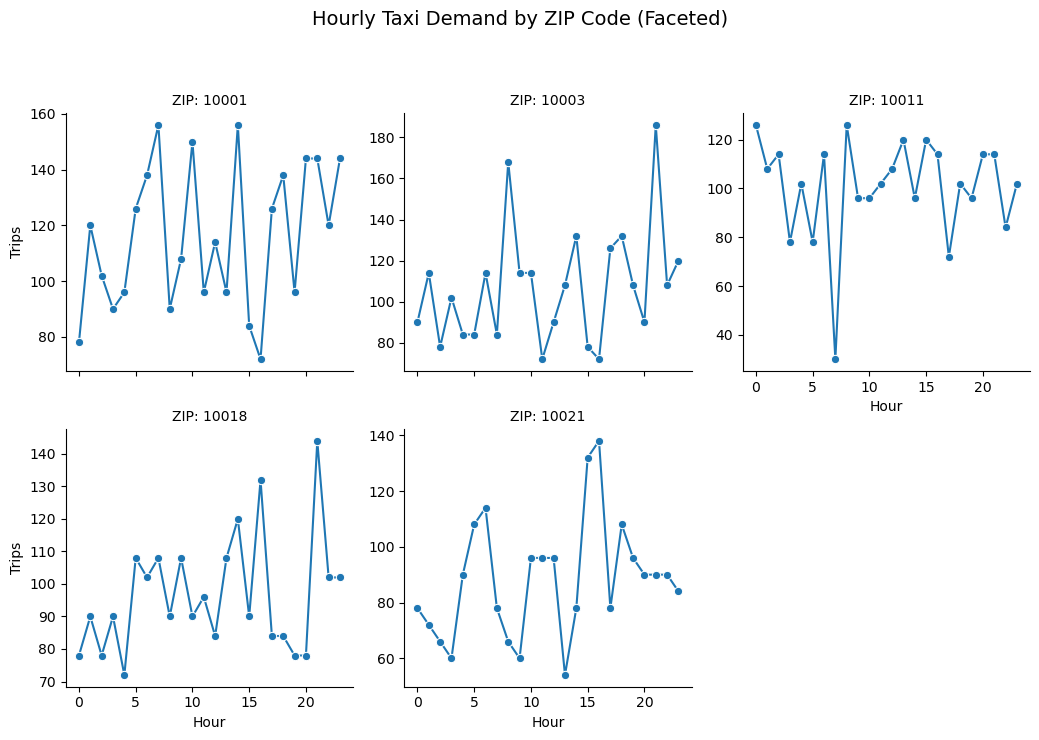

In [ ]:
#Facet Grid – Line Plot by ZIP (Top 5 in Subplots)

top6 = df_zip_hourly.groupby("pickup_zip")["trip_count"].sum().nlargest(5).index.tolist()
df_top6 = df_zip_hourly[df_zip_hourly["pickup_zip"].isin(top6)]

g = sns.FacetGrid(df_top6, col="pickup_zip", col_wrap=3, height=3.5, sharey=False)
g.map(sns.lineplot, "pickup_hour", "trip_count", marker="o")
g.set_titles("ZIP: {col_name}")
g.set_axis_labels("Hour", "Trips")
g.fig.suptitle("Hourly Taxi Demand by ZIP Code (Faceted)", y=1.05, fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
##Interactive Folium map showing the top 5 Manhattan ZIP codes by taxi demand using your ZIP-level taxi dataset

import folium
import pandas as pd

# === Load data ===
df_zip_hourly = pd.read_csv("Zip-query.csv")

# Extract pickup hour (just the hour from time string)
df_zip_hourly["pickup_hour"] = df_zip_hourly["tpep_pickup_datetime"].str.split(":").str[0]
df_zip_hourly = df_zip_hourly[df_zip_hourly["pickup_hour"].str.isnumeric()]
df_zip_hourly["pickup_hour"] = df_zip_hourly["pickup_hour"].astype(int)
df_zip_hourly = df_zip_hourly[df_zip_hourly["pickup_hour"].between(0, 23)]

# === Aggregate total trips per ZIP ===
df_zip_total = df_zip_hourly.groupby("pickup_zip").size().reset_index(name="trip_count")

# === Get Top 5 ZIPs ===
top_zip_codes = df_zip_total.sort_values(by="trip_count", ascending=False).head(5)

# === Hardcoded coordinates for ZIP codes (Manhattan examples) ===
zip_coords = {
    10001: {"lat": 40.7506, "lon": -73.9970, "area": "Chelsea"},
    10003: {"lat": 40.7323, "lon": -73.9895, "area": "East Village"},
    10011: {"lat": 40.7429, "lon": -74.0007, "area": "West Village"},
    10018: {"lat": 40.7553, "lon": -73.9933, "area": "Midtown"},
    10021: {"lat": 40.7680, "lon": -73.9580, "area": "Upper East Side"}
}

# === Initialize Folium Map ===
nyc_map = folium.Map(location=[40.75, -73.98], zoom_start=12, tiles="CartoDB positron")

# === Add circle markers ===
for _, row in top_zip_codes.iterrows():
    zip_code = int(row["pickup_zip"])
    trips = row["trip_count"]

    if zip_code in zip_coords:
        coords = zip_coords[zip_code]
        label = f"{zip_code} ({coords['area']}) - Trips: {trips:,}"

        folium.CircleMarker(
            location=[coords["lat"], coords["lon"]],
            radius=trips / 5000,  # Adjust radius scale
            color="blue",
            fill=True,
            fill_opacity=0.6,
            popup=label,
            tooltip=label
        ).add_to(nyc_map)

# === Save and open ===
output_path = "nyc_taxi_zip_demand_map.html"
nyc_map.save(output_path)
print(f"Map saved to: {output_path}")


Map saved to: nyc_taxi_zip_demand_map.html
